In [1]:
# importação das bibliotecas
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# define o dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
# carrega o FashionMNIST
data_folder = '~/data/FMNIST'
fmnist      = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images   = fmnist.data
tr_targets  = fmnist.targets

# printando as coisas
print('Imagens:', tr_images.shape, '| Classes:', tr_targets.unique())

Imagens: torch.Size([60000, 28, 28]) | Classes: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


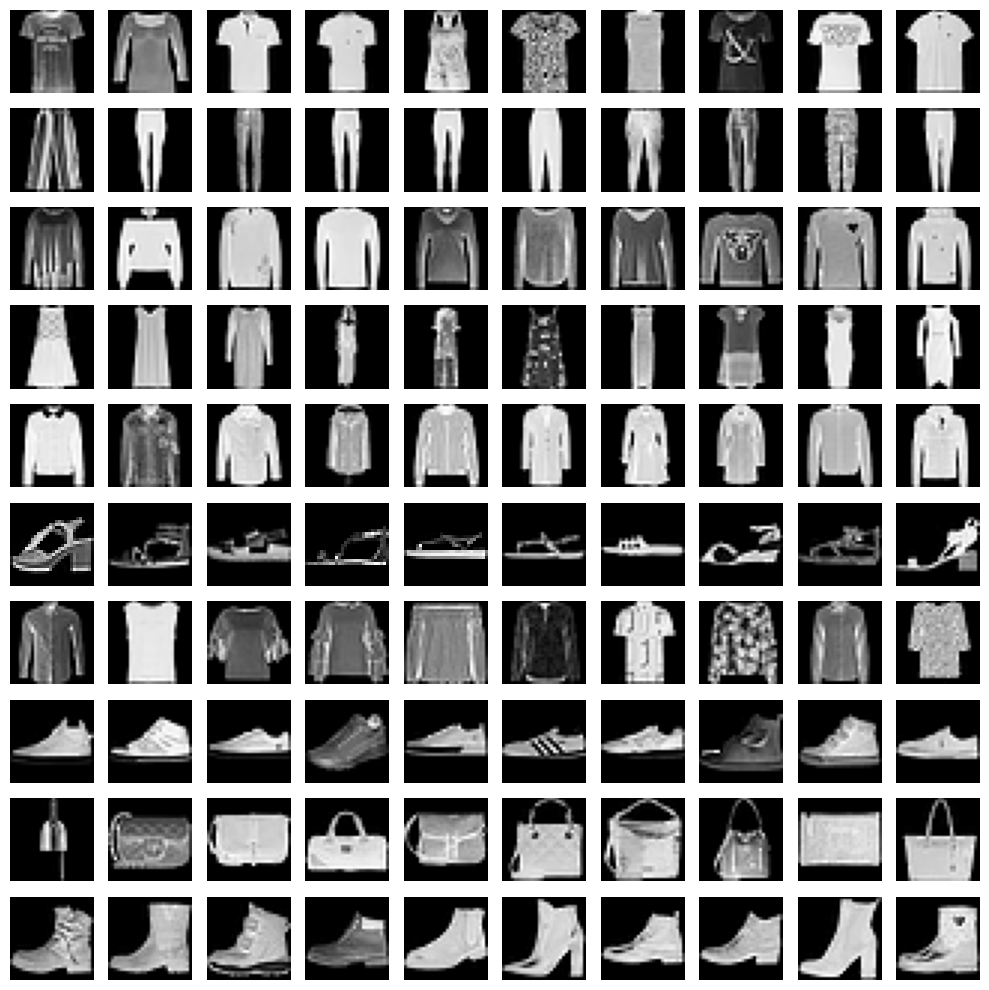

In [6]:
# exibe uma amostra de cada uma das 10 classes
R, C = len(tr_targets.unique()), 10
fig, ax = plt.subplots(R, C, figsize=(10, 10))

for label_class, plot_row in enumerate(ax): # itera pelas classes
    label_rows = np.where(tr_targets == label_class)[0] # indices da classe
    for cell in plot_row:
        cell.grid(False); cell.axis('off') # remove eixos
        ix = np.random.choice(label_rows) # escolhe imagem aleatória
        cell.imshow(tr_images[ix], cmap='gray') # plota em cinza

plt.tight_layout(); plt.show()

In [7]:
# dataset que achata cada imagem 28x28
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28)  # achata sem normalizar
        self.x, self.y = x, y

    def __getitem__(self, idx):
        # retorna o par imagem
        return self.x[idx].to(device), self.y[idx].to(device)

    def __len__(self):
        return len(self.x)

In [8]:
# cria o dataloader
def get_data():
    train  = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

In [9]:
# rede sequencial
def get_model():
    model = nn.Sequential(
        nn.Linear(28*28, 1000),  # entrada
        nn.ReLU(),               # ativação
        nn.Linear(1000, 10)      # saída
    ).to(device)
    loss_fn   = nn.CrossEntropyLoss()            # perda para classificação
    optimizer = SGD(model.parameters(), lr=1e-2) # otimizador SGD
    return model, loss_fn, optimizer

In [10]:
# treina um batch e retorna o erro
def train_batch(x, y, model, opt, loss_fn):
    model.train() # modo de treino
    prediction = model(x) # forward pass
    batch_loss = loss_fn(prediction, y) # calcula o erro
    batch_loss.backward() # backward pass
    opt.step() # atualiza os pesos
    opt.zero_grad() # limpa a memoria
    return batch_loss.item()

# calcula quantas previsoes
@torch.no_grad()
def accuracy(x, y, model):
    model.eval() # modo de avaliação
    prediction = model(x) # forward pass
    _, argmaxes = prediction.max(-1) # classe com maior score
    return (argmaxes == y).cpu().numpy().tolist()

In [11]:
# instancia dataloader e modelo
trn_dl = get_data()
model, loss_fn, optimizer = get_model()

In [14]:
# loop de treinamento
losses, accuracies = [], []

for epoch in range(5):
    print(f'{epoch+1}/5')
    epoch_losses, epoch_accs = [], []

    # treino percorre todos os batches
    for x, y in trn_dl:
        epoch_losses.append(train_batch(x, y, model, optimizer, loss_fn))

    # acuracia percorre
    for x, y in trn_dl:
        epoch_accs.extend(accuracy(x, y, model))

    # armazena as medias
    losses.append(np.mean(epoch_losses))
    accuracies.append(np.mean(epoch_accs))

1/5
2/5
3/5
4/5
5/5


/tmp/ipykernel_5550/2509905919.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


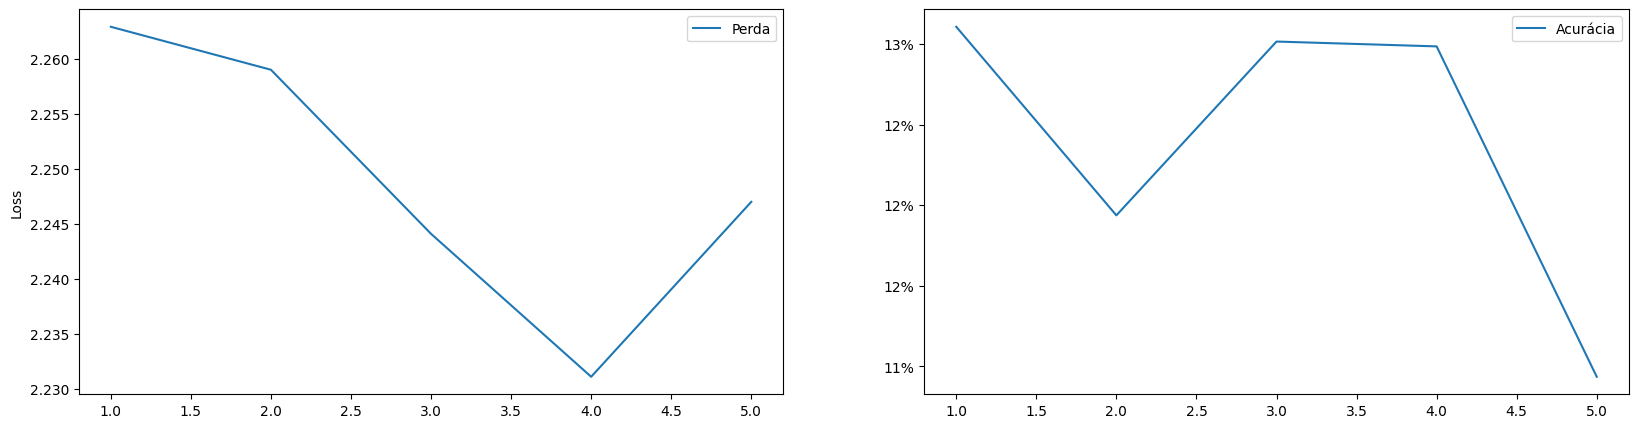

In [18]:
# plota a curva de perda e de acuracia
epochs = np.arange(5) + 1
plt.figure(figsize=(20, 5))

plt.subplot(121)
plt.plot(epochs, losses, label='Perda')
plt.title; plt.xlabel; plt.ylabel('Loss')
plt.legend()

plt.subplot(122)
plt.plot(epochs, accuracies, label='Acurácia')
plt.title; plt.xlabel
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.show()